In [1]:
import sys
print(sys.version)

import importlib.metadata as metadata
print("scikit-learn:", metadata.version("scikit-learn"))
print("joblib:", metadata.version("joblib"))
print("numpy:", metadata.version("numpy"))
print("pandas:", metadata.version("pandas"))

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
joblib: 1.5.3
numpy: 2.0.2
pandas: 2.2.2


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import joblib
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]

# URLs
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

# Read training data
train_df = pd.read_csv(
    train_url,
    names=columns,
    skipinitialspace=True,
    na_values="?"
)

# Read test data
test_df = pd.read_csv(
    test_url,
    names=columns,
    skiprows=1,          # Skip metadata line
    skipinitialspace=True,
    na_values="?"
)

# Remove trailing period from test labels (>50K. -> >50K)
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

# Combine train and test
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Dataset Shape : {df.shape}")
df.head()

Dataset Shape : (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("First 5 Rows")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Duplicate Rows")
print("=" * 60)
print(df.duplicated().sum())

print("\n" + "=" * 60)
print("Target Variable Distribution")
print("=" * 60)
print(df["income"].value_counts())

print("\n" + "=" * 60)
print("Statistical Summary (Numerical Features)")
print("=" * 60)
display(df.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Dataset Shape
(48842, 15)

First 5 Rows


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Missing Values
age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
dtype: int64

Duplicate Rows
52

Target Variable Distribution
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Statistical Summary (Numerical Features)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Remove duplicate records
print(f"Rows before removing duplicates : {df.shape[0]}")
df.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates  : {df.shape[0]}")

# Remove rows containing missing values
print(f"\nRows before removing missing values : {df.shape[0]}")
df.dropna(inplace=True)
print(f"Rows after removing missing values  : {df.shape[0]}")

# Remove leading/trailing spaces from object columns
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].str.strip()

# Verify cleaning
print("\nRemaining Missing Values")
print(df.isnull().sum())

print("\nDataset Shape After Cleaning")
print(df.shape)

print("\nTarget Distribution")
print(df["income"].value_counts())

Rows before removing duplicates : 48842
Rows after removing duplicates  : 48790

Rows before removing missing values : 48790
Rows after removing missing values  : 45175

Remaining Missing Values
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Dataset Shape After Cleaning
(45175, 15)

Target Distribution
income
<=50K    33973
>50K     11202
Name: count, dtype: int64


In [ ]:
# Separate features and target
X = df.drop("income", axis=1)
y = df["income"]

# Convert target variable into binary values
# <=50K -> 0
# >50K  -> 1
y = y.map({
    "<=50K": 0,
    ">50K": 1
})

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False),
         categorical_features)
    ]
)

print("\nPreprocessor created successfully.")

Numerical Features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical Features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Preprocessor created successfully.


In [ ]:
import os

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Set : {X_train.shape}")
print(f"Testing Set  : {X_test.shape}")

# Create models directory
os.makedirs("models", exist_ok=True)

# Save test data for Streamlit
test_data = X_test.copy()
test_data["income"] = y_test

test_data.to_csv("test_data.csv", index=False)

print("\n✓ test_data.csv created successfully")
print("✓ models folder created successfully")

Training Set : (36140, 14)
Testing Set  : (9035, 14)

✓ test_data.csv created successfully
✓ models folder created successfully


In [ ]:
from sklearn.base import clone

# Store model evaluation results
results = []

def train_and_evaluate(model_name, classifier):
    """
    Trains, evaluates and saves a model.
    """

    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clone(classifier))
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Save model
    joblib.dump(
        pipeline,
        f"models/{model_name.lower().replace(' ', '_')}.pkl"
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC": auc,
        "MCC": mcc
    })

    print(f" {model_name} trained and saved.")

In [ ]:
train_and_evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42)
)

 Logistic Regression trained and saved.


In [ ]:
train_and_evaluate(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42)
)

 Decision Tree trained and saved.


In [ ]:
train_and_evaluate(
    "KNN",
    KNeighborsClassifier(n_neighbors=5)
)

 KNN trained and saved.


In [ ]:
train_and_evaluate(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
)

 Random Forest trained and saved.


In [ ]:
train_and_evaluate(
    "Naive Bayes",
    GaussianNB()
)

 Naive Bayes trained and saved.


In [ ]:
# Create comparison DataFrame
results_df = pd.DataFrame(results)

# Sort by Accuracy (descending)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

# Round values for better readability
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC", "MCC"]
results_df[metric_columns] = results_df[metric_columns].round(4)

print("Model Performance Comparison")
display(results_df)

results_df.to_csv("model_comparison.csv", index = False)

# Best model
best_model = results_df.iloc[0]["Model"]
print(f"\n Best Model: {best_model}")

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score,AUC,MCC
0,Random Forest,0.8480,0.7322,0.6103,0.6657,0.8996,0.5724
1,Logistic Regression,0.8437,0.7308,0.5853,0.6500,0.9013,0.5566
2,KNN,0.8250,0.6668,0.5879,0.6249,0.8539,0.5131
3,Decision Tree,0.8071,0.6091,0.6192,0.6141,0.7442,0.4856
4,Naive Bayes,0.6068,0.3793,0.9210,0.5373,0.8249,0.3742



 Best Model: Random Forest


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_saved_model(model_name):
    """
    Loads a saved model and displays its evaluation.
    """

    filename = model_name.lower().replace(" ", "_")
    pipeline = joblib.load(f"models/{filename}.pkl")

    y_pred = pipeline.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

Logistic Regression

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6795
           1       0.73      0.59      0.65      2240

    accuracy                           0.84      9035
   macro avg       0.80      0.76      0.77      9035
weighted avg       0.84      0.84      0.84      9035



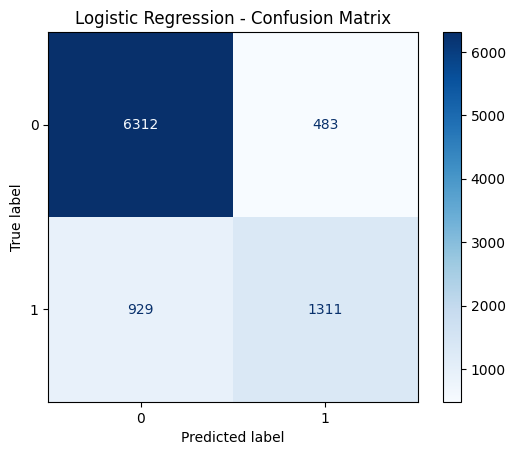

Decision Tree

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      6795
           1       0.61      0.62      0.61      2240

    accuracy                           0.81      9035
   macro avg       0.74      0.74      0.74      9035
weighted avg       0.81      0.81      0.81      9035



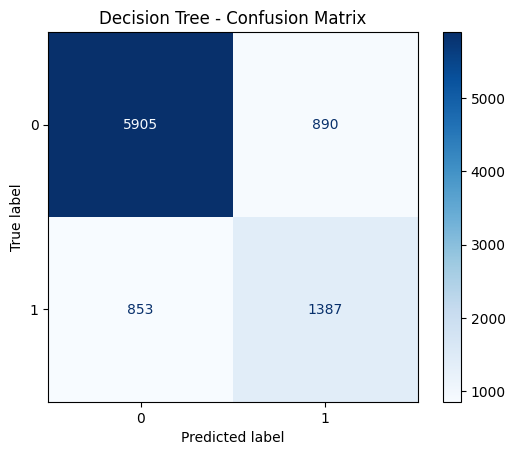

KNN

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      6795
           1       0.67      0.59      0.62      2240

    accuracy                           0.83      9035
   macro avg       0.77      0.75      0.76      9035
weighted avg       0.82      0.83      0.82      9035



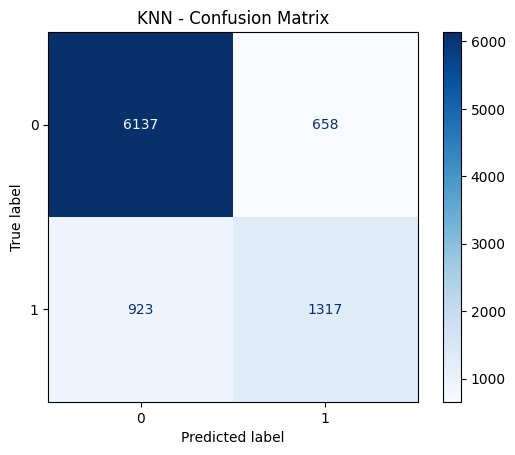

Naive Bayes

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.50      0.66      6795
           1       0.38      0.92      0.54      2240

    accuracy                           0.61      9035
   macro avg       0.67      0.71      0.60      9035
weighted avg       0.81      0.61      0.63      9035



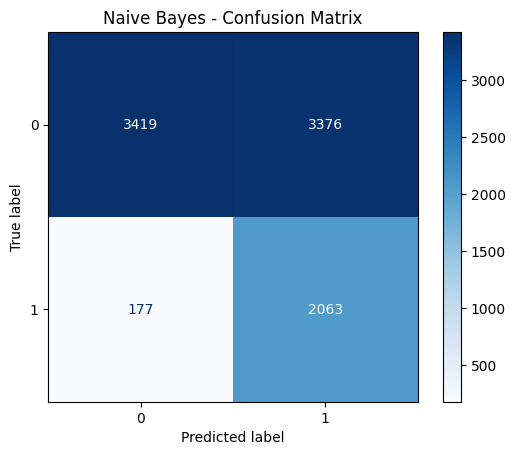

Random Forest

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6795
           1       0.73      0.61      0.67      2240

    accuracy                           0.85      9035
   macro avg       0.81      0.77      0.78      9035
weighted avg       0.84      0.85      0.84      9035



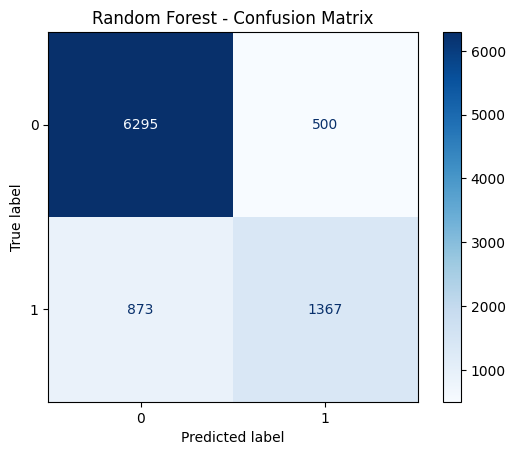

In [ ]:
evaluate_saved_model("Logistic Regression")
evaluate_saved_model("Decision Tree")
evaluate_saved_model("KNN")
evaluate_saved_model("Naive Bayes")
evaluate_saved_model("Random Forest")

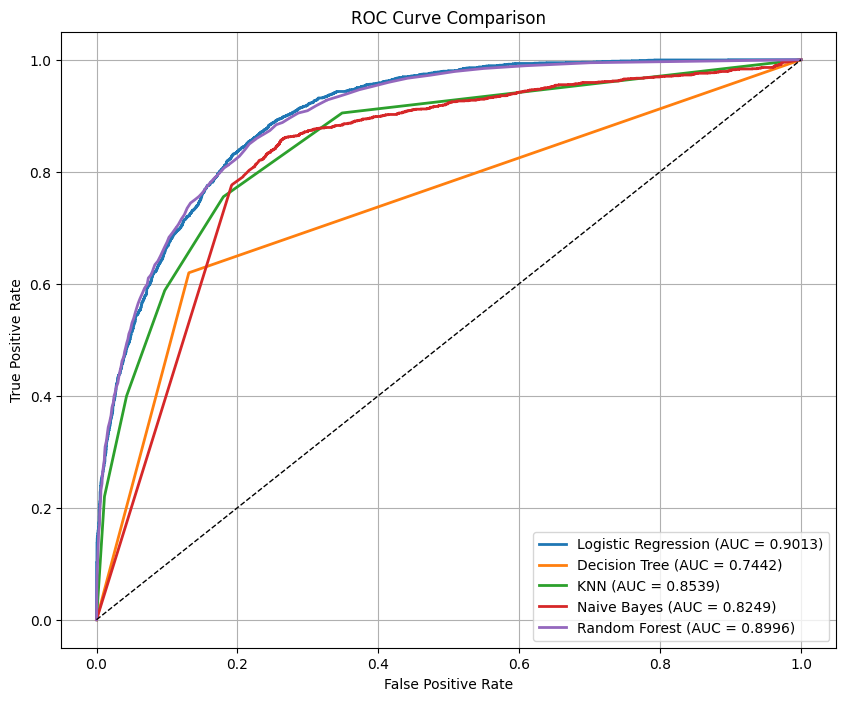

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN",
    "Naive Bayes",
    "Random Forest"
]

for model_name in models:

    filename = model_name.lower().replace(" ", "_")
    pipeline = joblib.load(f"models/{filename}.pkl")

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc:.4f})"
    )

# Random Guess line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Conclusion

In this project, five machine learning classification models were developed and evaluated using the Adult Census Income dataset to predict whether an individual's annual income exceeds \$50,000.

A complete machine learning pipeline was implemented, including data cleaning, preprocessing, feature encoding, feature scaling, model training, evaluation, and model persistence. The models were evaluated using Accuracy, Precision, Recall, F1 Score, Area Under the ROC Curve (AUC), and Matthews Correlation Coefficient (MCC).

Based on the experimental results, *Random Forest* achieved the best overall performance across the evaluation metrics and was selected as the final model for deployment.

All trained models were serialized as .pkl files using Joblib, enabling easy reuse without retraining. The saved models are integrated into a Streamlit web application that allows users to upload test data, select a classification model, and view predictions along with evaluation metrics and the confusion matrix.

This project demonstrates a complete end-to-end machine learning workflow, from data preprocessing and model development to deployment using Streamlit.

In [ ]:
import sys
import importlib.metadata as metadata

print("Python:", sys.version)
print("scikit-learn:", metadata.version("scikit-learn"))
print("joblib:", metadata.version("joblib"))
print("numpy:", metadata.version("numpy"))
print("pandas:", metadata.version("pandas"))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.6.1
joblib: 1.5.3
numpy: 2.0.2
pandas: 2.2.2
